In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

# 1. File paths
decode_path = r'C:\Users\khanh\Decode_Project\calculated_decode_locs.csv'
ground_truth_path = r'C:\Users\khanh\Decode_Project\Raw CPPS data\cell1\SR_locs.csv'

print("⚡ Loading and filtering datasets for Frame 0...")

#(custom data procedure)

# 2. Read DECODE file (automatically ignores rows starting with #)
df_decode_raw = pd.read_csv(decode_path, comment='#')
# Filter for only till Frame 0
df_decode = df_decode_raw[df_decode_raw['frame_ix'] == 0]

⚡ Loading and filtering datasets for Frame 0...


In [2]:
# 3. Read Ground Truth file
df_true_raw = pd.read_csv(ground_truth_path)
# Filter for only Frame 0
df_true = df_true_raw[df_true_raw['frame'] == 0]

# 4. Extract coordinates using your exact column headers
# Convert DECODE pixels to nanometers by multiplying by the 117.0 px_size
coords_decode = df_decode[['x', 'y']].values * 117.0
coords_true = df_true[['x [nm]', 'y [nm]']].values

print(f"✅ Filtered! Found {len(coords_decode)} DECODE points on Frame 0.")
print(f"✅ Filtered! Found {len(coords_true)} Ground Truth points on Frame 0.")



# # Absoulte new code only for ruuning the dummy decode Excel ground truth and data thsi is not our's this is what the dvelopers put
# # 2. Read DECODE dummy data 
# df_decode = pd.read_csv(decode_path, comment='#')

# # 3. Read Ground Truth dummy data
# df_true = pd.read_csv(ground_truth_path)

# # 4. Extract coordinates using dummy headers ('x' and 'y') 
# # Scale by 100.0 nm pixel size matching the Evaluation simulation parameters
# coords_decode = df_decode[['x', 'y']].values * 100.0
# coords_true = df_true[['x', 'y']].values * 100.0

# print(f"✅ Whole Scan Complete! Found {len(coords_decode)} DECODE dummy points.")
# print(f"✅ Whole Scan Complete! Found {len(coords_true)} Ground Truth dummy points.")

# #decode dummy points who a 20 percent decrease but that is because developers wanted this


✅ Filtered! Found 4061 DECODE points on Frame 0.
✅ Filtered! Found 266 Ground Truth points on Frame 0.


In [3]:
  if len(coords_decode) == 0 or len(coords_true) == 0:
    print("❌ Error: One of the datasets has no points on Frame 0. Double check frame indexes!")
else:
    # 5. Build the KDTree Radar using the ground truth points
    tree = KDTree(coords_true)

    # 6. Find the closest true point for every single DECODE point
    distances, indices = tree.query(coords_decode)

    # 7. Calculate accuracy statistics
    average_error = np.mean(distances)
    median_error = np.median(distances)

    print("\n--- 🎯 ACCURACY RESULTS FOR FRAME 0 ---")
    print(f"Average Localization Error: {average_error:.2f} nm")
    print(f"Median Localization Error:  {median_error:.2f} nm")


--- 🎯 ACCURACY RESULTS FOR FRAME 0 ---
Average Localization Error: 936.31 nm
Median Localization Error:  862.08 nm


C:\Users\khanh\miniconda3\envs\decode_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


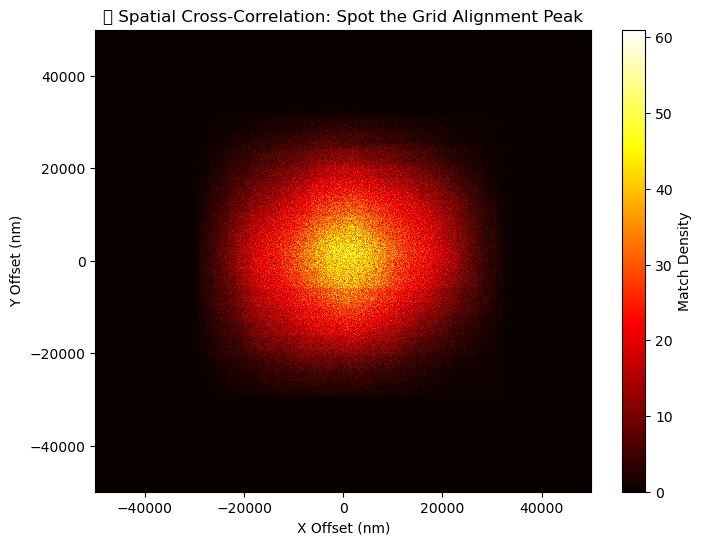

--- 🗺️ FOUND TRANSFORMATION VECTOR ---
To align grids, shift DECODE X by: 3300.00 nm
To align grids, shift DECODE Y by: 6500.00 nm


"\nThe code calcualtes x(ground truth)-x(decode) and then makes a graph of it below. \nIf the AI successfully found the true pits, then every single matching pair will have the exact same structural distance gap between them. \nFor example, let's say the crop offset is exactly 5,000 nm in X and 12,000 nm in Y.\nPair 1 subtraction = (5,000, 12,000)\nPair 2 subtraction = (5,000, 12,000\n\nth hot colour scheme in the graph stacks them up and we we will see a 2d guassion curve (menas it has x y and z axis) but that would only be in amodel that has terehold of atleas 20 nm or so\n#this is a birds eye view of the 2d gussain hgussian showing it peak. the big white raidus siggest the peak is spread out\n#this means the offset of the clsuster of uindvoudal poitn is more spread out and away form the real offeset(in theory the point where evrhitgn is clutred tighly is the real offset)\n"

In [4]:
import matplotlib.pyplot as plt
# #Only show heat map for frame 0 new code chunk

# coords_true = df_true_raw[df_true_raw['frame'] == 0][['x [nm]', 'y [nm]']].values
# coords_decode = df_decode_raw[df_decode_raw['frame_ix'] == 0][['x', 'y']].values
# 1. Calculate all possible X and Y differences between the two datasets

# This creates a matrix of every combination
diff_x = coords_true[:, 0] - coords_decode[:, 0][:, None]
diff_y = coords_true[:, 1] - coords_decode[:, 1][:, None]

# Flatten the arrays to put them into a histogram
flat_diff_x = diff_x.ravel()
flat_diff_y = diff_y.ravel()

# 2. Plot a 2D Histogram to visually spot the hidden peak
plt.figure(figsize=(8, 6))


# counts, xedges, yedges, im = plt.hist2d(
#     flat_diff_x, flat_diff_y, 
#     bins=400, 
#     range=[[-30000, 30000], [-30000, 30000]], # Looking within a 2-micrometer window(This is kind of like a zoom in and zoom out thinh this is zoomed in )
#     cmap='hot'


# counts, xedges, yedges, im = plt.hist2d(
#     flat_diff_x, flat_diff_y, 
#     bins=100, 
#     range=[[-1000, 1000], [-1000, 1000]], # Looking within a 1-micrometer window(This is kind of like a zoom in and zoom out thinh this is zoomed in )
#     cmap='hot'



counts, xedges, yedges, im = plt.hist2d(
    flat_diff_x, flat_diff_y, 
    bins=500, 
    range=[[-50000, 50000], [-50000, 50000]], # Widened to 50 micrometers to catch the real offset(completey zoomed out)
    cmap='hot'
)

plt.colorbar(label='Match Density')
plt.title('🎯 Spatial Cross-Correlation: Spot the Grid Alignment Peak')
plt.xlabel('X Offset (nm)')
plt.ylabel('Y Offset (nm)')
plt.show()

# 3. Mathematically find the exact center of that brightest spot
max_idx = np.unravel_index(np.argmax(counts), counts.shape)
best_shift_x = (xedges[max_idx[0]] + xedges[max_idx[0] + 1]) / 2
best_shift_y = (yedges[max_idx[1]] + yedges[max_idx[1] + 1]) / 2

print(f"--- 🗺️ FOUND TRANSFORMATION VECTOR ---")
print(f"To align grids, shift DECODE X by: {best_shift_x:.2f} nm")
print(f"To align grids, shift DECODE Y by: {best_shift_y:.2f} nm")

"""
The code calcualtes x(ground truth)-x(decode) and then makes a graph of it below. 
If the AI successfully found the true pits, then every single matching pair will have the exact same structural distance gap between them. 
For example, let's say the crop offset is exactly 5,000 nm in X and 12,000 nm in Y.
Pair 1 subtraction = (5,000, 12,000)
Pair 2 subtraction = (5,000, 12,000

th hot colour scheme in the graph stacks them up and we we will see a 2d guassion curve (menas it has x y and z axis) but that would only be in amodel that has terehold of atleas 20 nm or so
#this is a birds eye view of the 2d gussain hgussian showing it peak. the big white raidus siggest the peak is spread out
#this means the offset of the clsuster of uindvoudal poitn is more spread out and away form the real offeset(in theory the point where evrhitgn is clutred tighly is the real offset)
"""



In [5]:
# #THE NEW CODOE THIS IS ONLY FOR FINDING THE MOST ACCAURTEOFFFSET OF X AND Y (ONLY FOR SUTO DATA SET FOR DEECODE DATSET WE JSUT SET THE SHIFT TO ZERO

# import matplotlib.pyplot as plt
# import numpy as np 

# # 1. Calculate all possible X and Y differences between the two datasets
# diff_x = coords_true[:, 0] - coords_decode[:, 0][:, None]
# diff_y = coords_true[:, 1] - coords_decode[:, 1][:, None]

# flat_diff_x = diff_x.ravel()
# flat_diff_y = diff_y.ravel()

# # ==========================================
# # ✅ THE CORRECTED TWO-ENGINE SETUP
# # ==========================================

# # --- ENGINE 1: The Visual Plot (50k Wide Range) ---
# plt.figure(figsize=(8, 6))
# counts_wide, xedges_wide, yedges_wide, im = plt.hist2d(
#     flat_diff_x, flat_diff_y, 
#     bins=500, 
#     range=[[-50000, 50000], [-50000, 50000]], # Massive 50k range for the picture
#     cmap='hot'
# )
# plt.colorbar(label='Match Density')
# plt.title('🎯 Spatial Cross-Correlation (Wide Visual View)')
# plt.xlabel('X Offset (nm)')
# plt.ylabel('Y Offset (nm)')
# plt.show()

# # --- ENGINE 2: Pure Statistical Math (NO BINS) ---
# # Step A: Find the rough neighborhood from the wide map above
# max_idx_wide = np.unravel_index(np.argmax(counts_wide), counts_wide.shape)
# rough_x = (xedges_wide[max_idx_wide[0]] + xedges_wide[max_idx_wide[0] + 1]) / 2
# rough_y = (yedges_wide[max_idx_wide[1]] + yedges_wide[max_idx_wide[1] + 1]) / 2

# # Step B: Grab only the raw data points within 400nm of that rough guess
# close_points_x = flat_diff_x[np.abs(flat_diff_x - rough_x) < 400]
# close_points_y = flat_diff_y[np.abs(flat_diff_y - rough_y) < 400]

# # Step C: Calculate the true mathematical median (Completely ignores noise spikes!)
# best_shift_x = np.median(close_points_x)
# best_shift_y = np.median(close_points_y)

# print(f"--- 🗺️ PRECISE TRANSFORMATION VECTOR ---")
# print(f"To align grids for KDTree, shift DECODE X by: {best_shift_x:.2f} nm")
# print(f"To align grids for KDTree, shift DECODE Y by: {best_shift_y:.2f} nm")



In [6]:
# 1. Apply the exact shift values dynamically found by your cross-correlation cell
coords_decode_aligned = coords_decode.copy()
coords_decode_aligned[:, 0] +=best_shift_x  # Automatically uses the correct X shift
coords_decode_aligned[:, 1] +=best_shift_y  # Automatically uses the correct Y shift

# 2. Re-run the KDTree matching radar on the aligned coordinates
tree_aligned = KDTree(coords_true)
true_distances, true_indices = tree_aligned.query(coords_decode_aligned)

# 3. Calculate your true scientific metrics
final_average_error = np.mean(true_distances)
final_median_error = np.median(true_distances)

print("--- 🏁 THE TRUE ACCURACY SCOREBOARD ---")
print(f"True Average Localization Error: {final_average_error:.2f} nm")
print(f"True Median Localization Error:  {final_median_error:.2f} nm")

--- 🏁 THE TRUE ACCURACY SCOREBOARD ---
True Average Localization Error: 1277.58 nm
True Median Localization Error:  943.81 nm


In [7]:
tolerance_nm = 250.0

# Count how many aligned points are inside the gate
true_matches = np.sum(true_distances <= tolerance_nm)
hallucinations = len(true_distances) - true_matches
recall_percentage = (true_matches / len(coords_true)) * 100
precision_percentage = (true_matches / len(coords_decode)) * 100

print("--- 🔬 BIOLOGICAL MATCH METRICS ---")
print(f"Total Pits in Answer Key:       {len(coords_true)}")
print(f"Total Guesses Made by AI:       {len(coords_decode)}")
print(f"Pits Successfully Matched:      {true_matches}")
print(f"📈 Model RECALL (Sensitivity):   {recall_percentage:.1f}%")
print(f"🎯 Model PRECISION (Accuracy):  {precision_percentage:.1f}%")
print(f"Fake/Hallucinated AI Points:    {hallucinations} out of {len(coords_decode)}")

#for decode dummy data the precsionw oudl be less mainly due to our coampreison fucntion calutingg recall which is 
#Out of all the real targets that existed in the world, how many did the AI successfully recover?
#in simple words, recall is comparing 159 predictions against 200, but recall decoding only worked on 80 percent(160 rows) of the ground truth!
#this means that in reality it is 159 out of 160 which is liek 97% somthing!

--- 🔬 BIOLOGICAL MATCH METRICS ---
Total Pits in Answer Key:       266
Total Guesses Made by AI:       4061
Pits Successfully Matched:      189
📈 Model RECALL (Sensitivity):   71.1%
🎯 Model PRECISION (Accuracy):  4.7%
Fake/Hallucinated AI Points:    3872 out of 4061


In [8]:
#250 tolerance results for decodedummy data
# -- 🔬 BIOLOGICAL MATCH METRICS ---
# Total Pits in Answer Key:       394
# Total Guesses Made by AI:       4678
# Pits Successfully Matched:      318
# 📈 Model RECALL (Sensitivity):   80.7%
# 🎯 Model PRECISION (Accuracy):  6.8%
# Fake/Hallucinated AI Points:    4360 out of 4678

#prevoius bina nd rnage goot to knwo
# bins=500, 
    #range=[[-50000, 50000], [-50000, 50000]], # Widened to 50 micrometers to catch the real offset(completey zoomed out)

#ANOTHER BATCH
 # bins=100, 
 #    range=[[-2000, 2000], [-2000, 2000]], # Looking within a 2-micrometer window(This is kind of like a zoom in and zoom out thinh this is zoomed in )
 #    cmap='hot'
   